<h1 align="center" style="font-size:38px">MRI-Based Brain Age Estimation</h1>

Inspired by the groundbreaking paper titled "**[Accurate brain‐age models for routine clinical MRI examinations](https://www.sciencedirect.com/science/article/pii/S1053811922000015?via%3Dihub)**", this project develops an advanced predictive model using volumetric features extracted with **SynthSeg (FreeSurfer)** from high-resolution **3D T1-w brain MRIs**. It aims to estimate brain age accurately, detecting subtle deviations between chronological and biological brain age, that provide evidence that Alzheimer’s Disease is strongly associated with patterns of accelerated brain ageing.

The analysis involved two complementary approaches to explore the relationship between brain structure, age, and Alzheimer’s Disease. The first approach focused on **Brain Age Estimation and Brain PAD**, where a multiple polynomial regression model was trained using data from CN subjects, with chronological age as the dependent variable and volumetric features as independent variables. The model was then used to infer the brain age of AD subjects. The **Brain Predicted Age Difference (Brain PAD)**, calculated as the difference between predicted brain age and chronological age, demonstrated that AD patients exhibit significantly higher Brain PAD values compared to CN patients, providing evidence of accelerated brain aging in Alzheimer’s Disease.

The second approach employed **Classification Using Quadratic Discriminant Analysis** to distinguish between CN and AD subjects. A QDA classifier was carefully trained using selected brain volumes and age as features, aiming to find the quadratic combination of these features that best separates the two diagnostic groups. By maximizing the separation between the classes while minimizing the variance within each class, the model effectively captured the differences in brain volumes and their relationship with age. This enabled a reliable and consistent distinction between cognitively normal individuals and those diagnosed with Alzheimer’s Disease.

## Environment Configuration

In [1]:
%%capture
%pip install numpy==1.26.4
%pip install pandas==2.2.2
%pip install seaborn==0.13.2
%pip install matplotlib==3.8.4
%pip install scikit-learn==1.5.2

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from typing import Union

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GroupShuffleSplit
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
sns.set_theme(style='whitegrid', context='paper')

## Utility Functions

This section serves as a collection of reusable code snippets that enhance the clarity and modularity of the project. These functions simplify repetitive tasks and streamline the main analysis pipeline, ensuring the code remains **clean** and **maintainable**. By abstracting frequently used operations, they improve both the efficiency and **readability** of the notebook.

In [4]:
# Removes outliers from predicted age data based on the difference between predicted and true values.
# The threshold is defined as the 95th percentile of the absolute differences.
# Author: Antonio Scardace
# Version: 1.0

def remove_outliers(true_age: pd.Series, predicted_age: np.ndarray) -> tuple[pd.Series, np.ndarray]:
    delta = np.abs(predicted_age - true_age)
    threshold = np.percentile(delta, 95)
    return true_age[delta <= threshold], predicted_age[delta <= threshold]

# Plots a chart for a given data series.
# Allows flexibility to choose the type of chart, color, and axis labels.
# Author: Antonio Scardace
# Version: 1.0

def plot_chart(data: pd.Series, kind: str, color: Union[str, list[str]], ylabel: str) -> None:
    data.plot(kind=kind, color=color, figsize=(4, 3), rot=0)
    plt.ylabel(ylabel, labelpad=16)
    plt.xlabel('')
    plt.show()

# Plots a scatterplot of predicted vs true age and the ideal fit line (y=x).
# Allows flexibility to choose the color and the label.
# Author: Antonio Scardace
# Version: 1.0

def plot_age_scatter(true_age: pd.Series, pred_age: np.ndarray, ax: plt.Axes, color: str, label: str) -> None:
    sns.set_theme(style='whitegrid', palette='muted')
    sns.scatterplot(x=true_age, y=pred_age, color=color, label=label, ax=ax, alpha=0.6, s=20)
    sns.lineplot(x=true_age, y=true_age, color='black', ax=ax, label='Ideal Fit', linewidth=1)
    ax.set_xlabel('True Age (years)', labelpad=16)
    ax.set_ylabel('Predicted Age (years)', labelpad=16)
    ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

## Dataset Presentation

The [volumes CSV](/data/raw/volumes.csv) obtained from SynthSeg, measured in millimeters cubed (mm<sup>3</sup>), was merged with a [metadata CSV](/data/raw/metadata.csv) containing demographic information to form the [final dataset](/data/processed/merged_dataset.csv). For analysis, I prepared a [normalised CSV file](/data/processed/normalised_dataset.csv) focusing on volumes of brain regions that are relevant to both CN and AD subjects. Left and right hemisphere volumes were summed for each structure, and all values were normalised by total head size to ensure comparability across subjects. To facilitate regression and classification algorithms, categorical variables were converted into dummy variables: `sex` was transformed from `M` and `F` to `0` and `1`, respectively, and `diagnosis` from `CN` and `AD` to `0` and `1`, respectively.<br/><br/>

In [5]:
DATASET_PATH = '../data/interim/merged_dataset.csv'
dataset = pd.read_csv(DATASET_PATH)

In [6]:
NORMALISED_DATASET_PATH = '../data/processed/normalised_dataset.csv'
normalised_dataset = pd.read_csv(NORMALISED_DATASET_PATH)

## Dataset Overview: Exploratory Data Analysis (EDA)

This section provides an overview of the dataset, which comprises 2,227 subjects and 7,545 scans. It includes a range of demographic and diagnostic variables, enabling a comprehensive exploratory data analysis (EDA).

The cohort is nearly balanced in terms of sex, with 50.8% female and 49.2% male participants. Data are drawn from three primary sources, with the majority originating from ADNI (69.5%), followed by OASIS (21.42%) and AIBL (9.08%). Subjects are also categorized by diagnosis: 68.68% are cognitively normal (CN), while 31.32% have been diagnosed with Alzheimer’s Disease. The dataset spans a broad age range, from 43 to 96 years. The median age is 75 years, while the mean age is slightly lower at 74.28 years (standard deviation: 7.76 years). The age distribution is mildly negatively skewed (skewness = -0.33), indicating a slight bias toward older individuals, though it remains relatively well balanced. This is consistent with the nature of the dataset, which is enriched for studies on Alzheimer’s disease and brain ageing. Importantly, this age distribution aligns with the population most affected by AD, enhancing the dataset’s relevance for investigating brain health. Overall, the dataset is well suited for exploring the relationship between brain ageing, sex differences, and Alzheimer’s disease. The balanced sex distribution helps reduce demographic bias, while the diagnostic composition and age range provide insight into both normal and pathological ageing. Although the skew toward older ages is appropriate given the focus on Alzheimer’s disease, it requires careful stratification during analysis to ensure that findings remain representative.

In [7]:
print('Analysed', dataset['subject_id'].drop_duplicates().count(), 'subjects')
print('Analysed', dataset['image_id'].count(), 'scans')

Analysed 2227 subjects
Analysed 7545 scans


In [8]:
sex_counts_df = dataset['sex'].value_counts().to_frame().reset_index()
sex_counts_df['percentage'] = (sex_counts_df['count'] / len(dataset) * 100).round(2)
sex_counts_df

,sex,count,percentage
0,F,3833,50.8
1,M,3712,49.2


In [9]:
dataset_name_counts_df = dataset['dataset_name'].value_counts().to_frame().reset_index()
dataset_name_counts_df['percentage'] = (dataset_name_counts_df['count'] / len(dataset) * 100).round(2)
dataset_name_counts_df

,dataset_name,count,percentage
0,ADNI,5244,69.50
1,OASIS,1616,21.42
2,AIBL,685,9.08


In [10]:
diagnosis_counts_df = dataset['diagnosis'].value_counts().to_frame().reset_index()
diagnosis_counts_df['percentage'] = (diagnosis_counts_df['count'] / len(dataset) * 100).round(2)
diagnosis_counts_df

,diagnosis,count,percentage
0,CN,5182,68.68
1,AD,2363,31.32


In [11]:
print('Minimum Age:', dataset['age'].min(), 'years')
print('Maximum Age:', dataset['age'].max(), 'years')
print('Median Age:', dataset['age'].median(), 'years')
print('Mean Age:', round(dataset['age'].mean(), 2), 'years')
print('Standard Deviation:', round(dataset['age'].std(), 2), 'years')
print('Skewness:', round(dataset['age'].skew(), 2))

Minimum Age: 43 years
Maximum Age: 96 years
Median Age: 75.0 years
Mean Age: 74.28 years
Standard Deviation: 7.76 years
Skewness: -0.33


## Dataset Overview: Visualisation

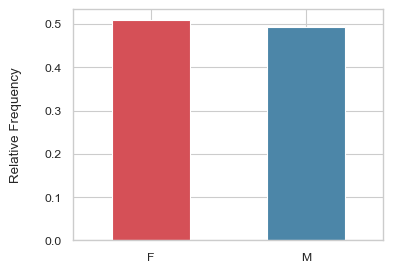

In [12]:
sex_counts = dataset['sex'].value_counts(normalize=True)
plot_chart(sex_counts, 'bar', ['#D55057', '#4C86A8'], 'Relative Frequency')

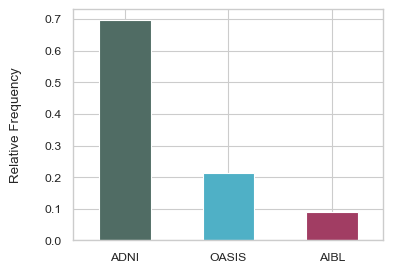

In [13]:
dataset_name_counts = dataset['dataset_name'].value_counts(normalize=True)
plot_chart(dataset_name_counts, 'bar', ['#506C64', '#4FB0C6', '#A13D63'], 'Relative Frequency')

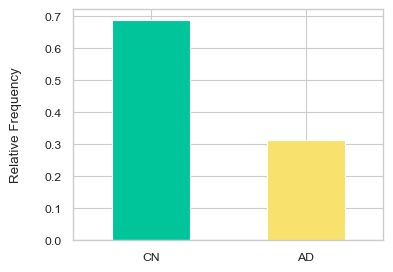

In [14]:
diagnosis_counts = dataset['diagnosis'].value_counts(normalize=True)
plot_chart(diagnosis_counts, 'bar', ['#00C49A', '#F8E16C'], 'Relative Frequency')

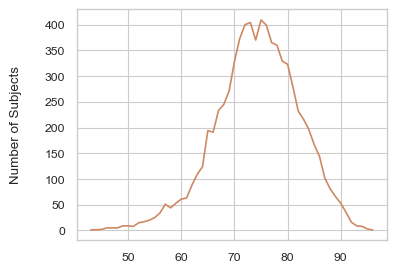

In [15]:
age_counts = dataset['age'].value_counts().sort_index()
plot_chart(age_counts, 'line', '#CE8964', 'Number of Subjects')

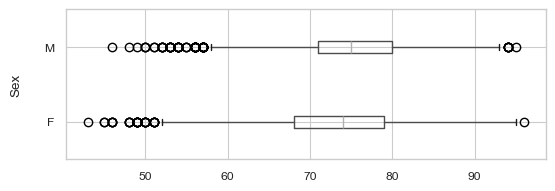

In [16]:
dataset.boxplot(column=['age'], by='sex', figsize=(6, 2), vert=False)
plt.ylabel('Sex', labelpad=16)
plt.suptitle('')
plt.title('')
plt.show()

## Training the BrainAge Regressor

After experimenting with various hyperparameters and models, a **third-degree polynomial regressor** with interaction terms and no regularization was selected as the optimal model. This choice was supported by rigorous **5-fold Cross-Validation**. The model demonstrated strong performance, achieving a Mean Absolute Error (MAE) of 4.42 years on the test set. These results are consistent with those reported in the reference study (`3 < MAE < 4`), which employed 3D MRI scans and a neural network.

The statistical significance of the independent variables was evaluated using p-values. Most variables exhibited __p-values < 0.05, whereas the `amygdala` feature showed a p-value > 0.05__, suggesting limited individual significance. However, backward elimination indicated that removing this feature slightly degraded model performance, as reflected by a decrease in R-squared and an increase in MAE. This suggests that retaining the `amygdala` contributes to the overall predictive performance of the model.

In [17]:
cn_data = normalised_dataset[normalised_dataset['diagnosis'] == 0]
ad_data = normalised_dataset[normalised_dataset['diagnosis'] == 1]

gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, test_idx = next(gss.split(cn_data, groups=cn_data['subject_id']))
cn_train_data = cn_data.iloc[train_idx]
cn_test_data = cn_data.iloc[test_idx]

print('Training set size:', len(cn_train_data), 'CN scans')
print('Test set size:', len(cn_test_data), 'CN scans')

Training set size: 3642 CN scans
Test set size: 1540 CN scans


In [18]:
independent_variables = [
    'sex',
    'third_ventricle',
    'fourth_ventricle',
    'csf',
    'head_size',
    'cerebral_white_matter',
    'cerebral_cortex',
    'lateral_ventricle',
    'inferior_lateral_ventricle',
    'thalamus',
    'hippocampus',
    'amygdala',
    'accumbens_area'
]

In [19]:
pipeline = Pipeline(memory=None, steps=[
    ('polynomial_features', PolynomialFeatures(degree=3, interaction_only=False)),
    ('linear_regression', LinearRegression())
])

pipeline.fit(cn_train_data[independent_variables], cn_train_data['chronological_age'])
y_train_pred = pipeline.predict(cn_train_data[independent_variables])
y_test_pred = pipeline.predict(cn_test_data[independent_variables])

print('R-squared Score:', round(r2_score(cn_train_data['chronological_age'], y_train_pred), 4))
print('Testing MAE:', round(mean_absolute_error(cn_test_data['chronological_age'], y_test_pred), 4), 'years')

R-squared Score: 0.5626
Testing MAE: 4.4272 years


## BrainPAD Metrics: Revealing Alzheimer’s Accelerated Ageing

This subsection analyzes Brain PAD (Predicted Age Difference), which measures the gap between an individual’s brain age and chronological age. It is a useful tool for assessing the alignment of biological and chronological aging, especially in conditions like Alzheimer’s Disease. Using the brain age regressor trained on CN data, we calculate the average **Brain PAD** for both CN and AD groups. For the CN group, the results show a close alignment between biological and chronological age, confirming the regressor’s accuracy. In contrast, the AD group exhibits a significant positive Brain PAD, indicating accelerated biological aging in Alzheimer’s, highlighting the substantial gap between brain and chronological age in this condition.

In [20]:
ad_predictions = pipeline.predict(ad_data[independent_variables])
cn_predictions = pipeline.predict(cn_test_data[independent_variables])

ad_mean_brain_pad = (ad_predictions - ad_data['chronological_age']).mean()
cn_mean_brain_pad = (cn_predictions - cn_test_data['chronological_age']).mean()
print('Mean Brain PAD for AD subjects:', ad_mean_brain_pad.round(2), 'years')
print('Mean Brain PAD for CN subjects:', cn_mean_brain_pad.round(2), 'years')

Mean Brain PAD for AD subjects: 5.32 years
Mean Brain PAD for CN subjects: -0.7 years


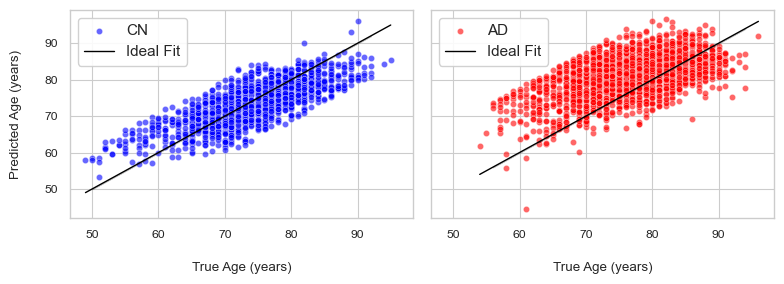

In [21]:
cn_true_age, cn_pred_age = remove_outliers(cn_test_data['chronological_age'], cn_predictions)
ad_true_age, ad_pred_age = remove_outliers(ad_data['chronological_age'], ad_predictions)

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True)
plot_age_scatter(cn_true_age, cn_pred_age, axes[0], color='blue', label='CN')
plot_age_scatter(ad_true_age, ad_pred_age, axes[1], color='red', label='AD')
plt.tight_layout()
plt.show()

## Training the BrainAge Classifier

For the classification model, I chose **Quadratic Discriminant Analysis (QDA)** due to its ability to capture non-linear boundaries between classes by leveraging quadratic combinations of the features. I benchmarked its performance against several other classifiers in the following order of performance: Linear Discriminant Analysis (LDA), Naive Bayes, K-Nearest Neighbors (KNN) with `K=4`, which all delivered comparable results. However, Maximum A Posteriori (MAP) lagged significantly behind the others, making QDA the clear choice. This comparison was conducted using a **validation set** to ensure the most suitable model was selected. The QDA classifier achieved an **Accuracy of 83%**, **F1-Score of 71%**, and **AUC of 78%**, demonstrating solid performance. What’s particularly notable is that this was accomplished without the complexity of using 3D MRI scans or deep learning models. In a [previous project](https://github.com/antonioscardace/Tina), I tested a CNN model using 3D MRI data with **MONAI’s DenseNet**, which outperformed the QDA in accuracy and other metrics. However, the QDA’s simpler approach, using selected brain volume features, achieved comparable results, highlighting its efficiency and ability to deliver strong performance without the need for computationally expensive 3D data and deep learning models.

In [22]:
gss_clf = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx_clf, test_idx_clf = next(gss_clf.split(normalised_dataset, groups=normalised_dataset['subject_id']))
train_data = normalised_dataset.iloc[train_idx_clf]
test_data = normalised_dataset.iloc[test_idx_clf]

print('Training set size:', len(train_data), 'scans')
print('Test set size:', len(test_data), 'scans')

Training set size: 5320 scans
Test set size: 2225 scans


In [23]:
features = [
    'chronological_age',
    'sex',
    'third_ventricle',
    'fourth_ventricle',
    'csf',
    'head_size',
    'cerebral_white_matter',
    'cerebral_cortex',
    'lateral_ventricle',
    'inferior_lateral_ventricle',
    'thalamus',
    'hippocampus',
    'amygdala',
    'accumbens_area'
]

In [24]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(train_data[features], train_data['diagnosis'])

y_true = test_data['diagnosis']
y_pred = qda.predict(test_data[features])

print('Test Accuracy:', round(accuracy_score(y_true, y_pred), 4))
print('Test Precision:', round(precision_score(y_true, y_pred), 4))
print('Test Recall:', round(recall_score(y_true, y_pred), 4))
print('Test F1-Score:', round(f1_score(y_true, y_pred), 4))
print('Test AUC:', round(roc_auc_score(y_true, y_pred), 4))

Test Accuracy: 0.84
Test Precision: 0.7912
Test Recall: 0.6667
Test F1-Score: 0.7236
Test AUC: 0.793


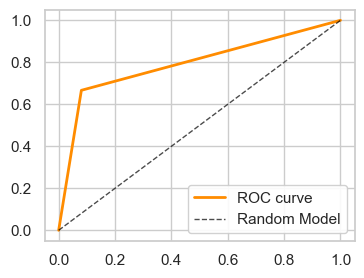

In [25]:
false_positive_rate, true_positive_rate, _ = roc_curve(y_true, y_pred)
plt.figure(figsize=(4, 3))
plt.plot(false_positive_rate, true_positive_rate, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='black', lw=1, alpha=0.7, linestyle='--', label='Random Model')
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.show()